**Problem Statement:** The sincking of titnac is one of the most infamous shipwrecks in the history while there was some element of luck involv in surviving certain groups of people more likely to surview then the others. The problem is to bulit ML model that predicts weather a passinger surviewed the titanic disaster based on given features


**Objectives:** 
1. To analyse pacenger data and identify key factors affecting survival 
2. to build a classification model that predicts survive = 1 if the passenger surviewed else surviwerd = 0
3. To evaluate model performance using appropriate metrix

**Type of Problem:**
1. Supervised Learning
2. Binary Classification
3. Target variable is Survieved

**Dataset Description:** The dataset contains information about individual passengers on board Titanic, target variable 

Column                                         Describtion
Survived                                       0:NO, 1:Yes

In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings 
warnings.filterwarnings("ignore")

In [59]:
df=pd.read_csv("titanic.csv")
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [60]:
df["Survived"].value_counts()
# dataset is imbalanced

Survived
0    549
1    342
Name: count, dtype: int64

In [61]:
df.info()
# null values and object type of columns are present

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [62]:
(df.isnull().sum()/len(df))*100

#Age            19.865320
#Cabin          77.104377
#Embarked        0.224467

# Rules of null processing:
# 0-3% : Drop the row
# 4-40%: replace the values
# >40  : drop the column

# so drop the column cabin, Age replace nulls by mean or median depending the distribution,
# if symmetric or normally distributed then replace with mean otherwise with median.
# Embark drop the row


PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [63]:
df.drop("Cabin",axis=1,inplace=True)

In [64]:
df["Age"].describe()
# mean      29.699118, 50%       28.000000
# little positive skewness

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: xlabel='Age', ylabel='Density'>

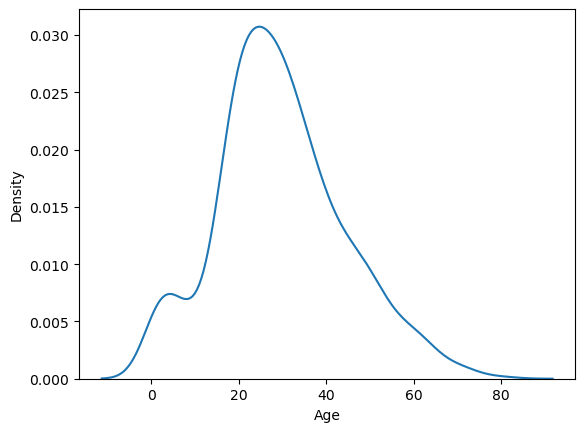

In [65]:
sns.kdeplot(df["Age"])

In [66]:
df["Age"].fillna(df["Age"].median(),inplace=True)
df["Age"].isnull().sum()

0

In [67]:
df.dropna(inplace=True)

In [68]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [69]:
# Statistical distribution check for outlier and skewness pre-processing

In [70]:
num_cols=df.select_dtypes(["int","float"]).columns
num_cols

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [71]:
df[num_cols].describe()
# based on domain knowledge we will be analysing and processing outlier and skewness of Age and Fare columns only
# +ve skewed: Age, Fare

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,2.311586,29.315152,0.524184,0.382452,32.096681
std,256.998173,0.486260,0.834700,12.984932,1.103705,0.806761,49.697504
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,224.000000,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.000000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: ylabel='Age'>

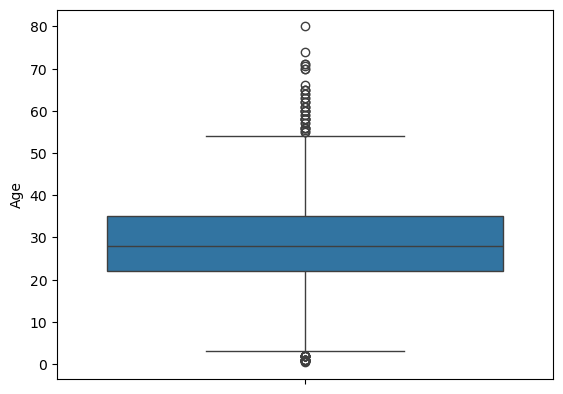

In [72]:
sns.boxplot(df["Age"])
# based on distribution of age column, outliers are present
# but based on domain knowledge we are not removing outliers because that could directly impact on survival chances.

<Axes: xlabel='Age', ylabel='Density'>

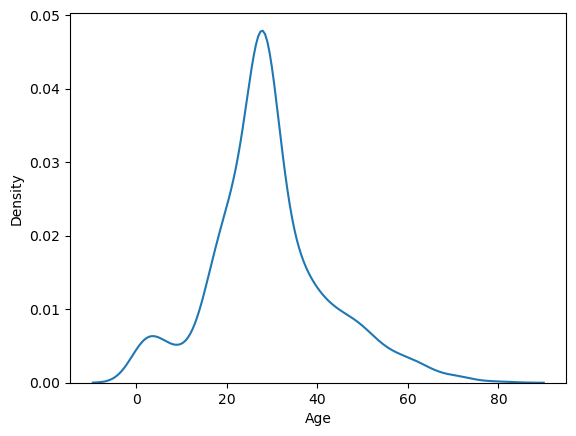

In [73]:
sns.kdeplot(df["Age"])
# many middle aged peoples are travelling 
# also few children in the age under 10 are also showing high density
# few old age people with age around 80 are also travelling

<Axes: xlabel='Fare', ylabel='Density'>

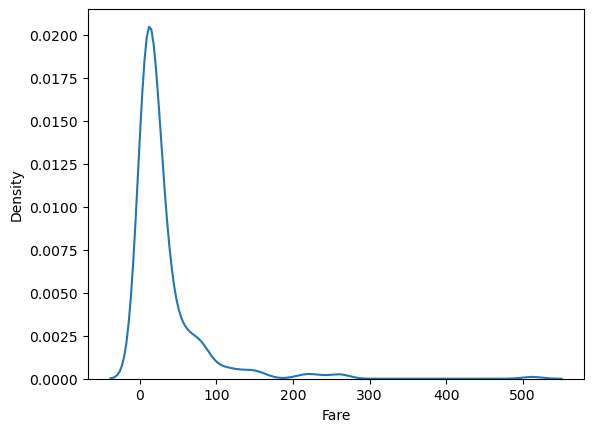

In [74]:
sns.kdeplot(df["Fare"])
# most of the people were travelling without paying money
# or paying a money less than $100
# and there are people who have paid more than $500

<Axes: ylabel='Fare'>

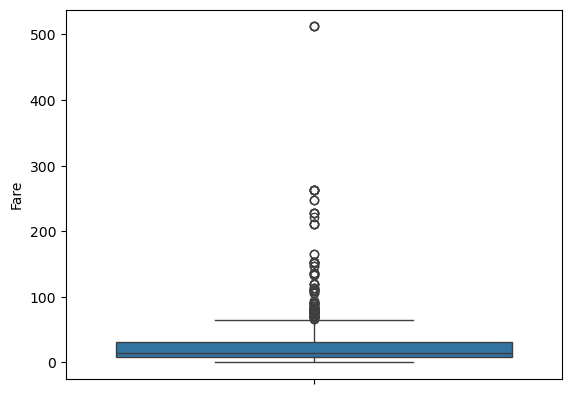

In [75]:
sns.boxplot(df["Fare"])
# again because fare can directly impact survival rate so not removing the outliers

In [76]:
# Skewness
from scipy.stats import skew
print(f"Skewness of Age: {skew(df["Age"])}")
print(f"Skewness of Fare: {skew(df["Fare"])}")

Skewness of Age: 0.507152516392603
Skewness of Fare: 4.793334993307843


In [77]:
# Based on domain knowledge, we are dropping certain columns
df.drop(["PassengerId","Name","Ticket"],axis=1,inplace=True)

In [78]:
# Object encoding
obj_cols=df.select_dtypes("object").columns
obj_cols

Index(['Sex', 'Embarked'], dtype='object')

In [79]:
for i in obj_cols:
    print(f"{i} : {df[i].value_counts()}")
# the columns are not well distributed
# more males than females are travelling
# many people onboarded from station S and least from station Q

Sex : Sex
male      577
female    312
Name: count, dtype: int64
Embarked : Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [80]:
# before encoding, we will check categorical data distribution
c=["Survived","Pclass","Parch","SibSp","Sex","Embarked"]
for i in c:
    print(f"{i} : {df[i].value_counts()}")

Survived : Survived
0    549
1    340
Name: count, dtype: int64
Pclass : Pclass
3    491
1    214
2    184
Name: count, dtype: int64
Parch : Parch
0    676
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64
SibSp : SibSp
0    606
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64
Sex : Sex
male      577
female    312
Name: count, dtype: int64
Embarked : Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


Survived


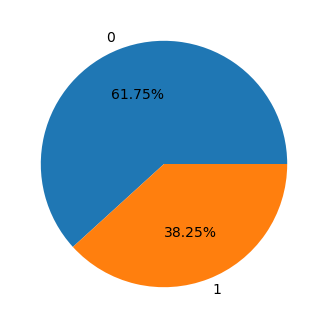

Pclass


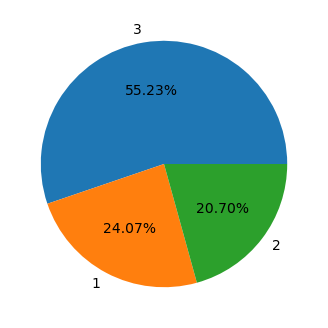

Parch


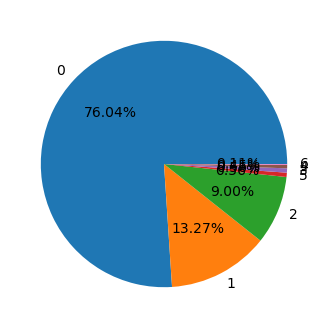

SibSp


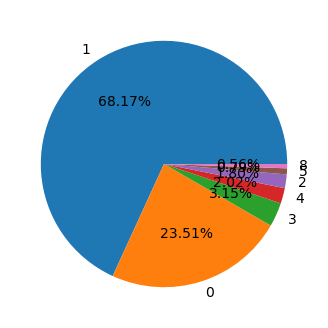

Sex


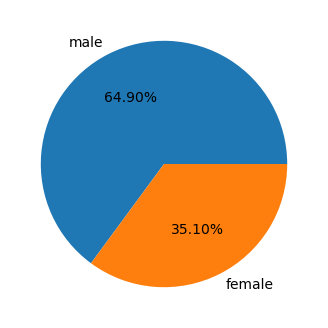

Embarked


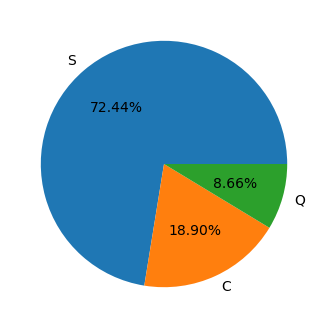

In [81]:
for i in c:
    plt.figure(figsize=(4,4))
    print(i)
    plt.pie(df[i].value_counts(),autopct="%.2f%%",labels=df[i].unique())
    plt.show()
# the distribution of data:-
# around 62% people died  and rest surviewed
# around 55% peoples were travelling from class3 and 24% from class1
# around 76% people were travelling without kids and 13% has single child
# around 68% people were travelling with spouse or sibling
# 65% male
#  72% people embarked from station S

In [82]:
for i in c:
    print(pd.crosstab(df["Survived"],df[i]))
    print('---------------------------------------')
# this is helping in understanding the data better and impact of different categorical coulmn on target
# which is again categorical
# class 3 people died the most while class 1 people survived more
# single person with no family and spouse died the most
# many male passenger died
# people embarked from S station died the most

Survived    0    1
Survived          
0         549    0
1           0  340
---------------------------------------
Pclass      1   2    3
Survived              
0          80  97  372
1         134  87  119
---------------------------------------
Parch       0   1   2  3  4  5  6
Survived                         
0         445  53  40  2  4  4  1
1         231  65  40  3  0  1  0
---------------------------------------
SibSp       0    1   2   3   4  5  8
Survived                            
0         398   97  15  12  15  5  7
1         208  112  13   4   3  0  0
---------------------------------------
Sex       female  male
Survived              
0             81   468
1            231   109
---------------------------------------
Embarked   C   Q    S
Survived             
0         75  47  427
1         93  30  217
---------------------------------------


Age


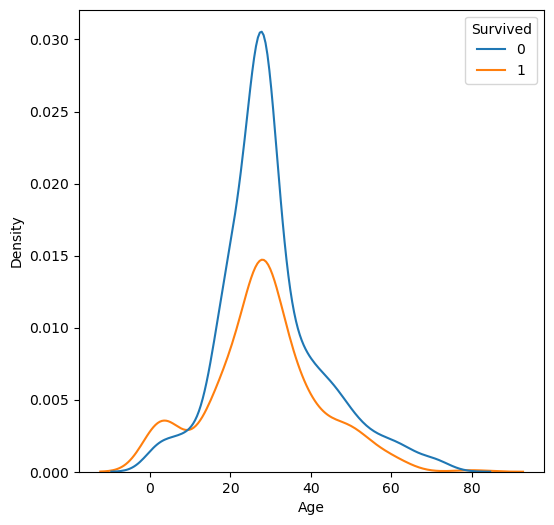

Fare


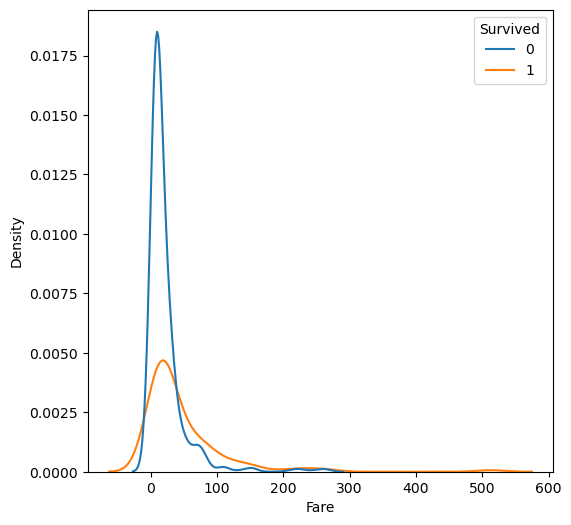

In [83]:
# how target is getting affected by these numerical coulmns
n=["Age","Fare"]
for i in n:
    print(i)
    plt.figure(figsize=(6,6))
    sns.kdeplot(data=df,x=i,hue="Survived")
    plt.show()
# age column is not helping at all in survival chance prediction
# the density plot is completely overlapped
# Fare, Here those who have payed more than $300 are likely to survive

In [84]:
# feature engineering
df["FamilySize"]=df["Parch"]+df["SibSp"]
df.drop(["SibSp","Parch"],axis=1,inplace=True)
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize
0,0,3,male,22.0,7.2500,S,1
1,1,1,female,38.0,71.2833,C,1
2,1,3,female,26.0,7.9250,S,0
3,1,1,female,35.0,53.1000,S,1
4,0,3,male,35.0,8.0500,S,0


In [85]:
a=["Sex","Embarked"]
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
df[a]=oe.fit_transform(df[a])
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize
0,0,3,1.0,22.0,7.2500,2.0,1
1,1,1,0.0,38.0,71.2833,0.0,1
2,1,3,0.0,26.0,7.9250,2.0,0
3,1,1,0.0,35.0,53.1000,2.0,1
4,0,3,1.0,35.0,8.0500,2.0,0


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    889 non-null    int64  
 1   Pclass      889 non-null    int64  
 2   Sex         889 non-null    float64
 3   Age         889 non-null    float64
 4   Fare        889 non-null    float64
 5   Embarked    889 non-null    float64
 6   FamilySize  889 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 55.6 KB


In [87]:
features=df.drop("Survived",axis=1)
target=df["Survived"]

In [88]:
# Scalling
# MinMaxScaling because the data is not normally distributed
# i.e skewness and outliers are present
from sklearn.preprocessing import MinMaxScaler
mm=MinMaxScaler()
features.iloc[:]=mm.fit_transform(features.iloc[:])
features.head()

,Pclass,Sex,Age,Fare,Embarked,FamilySize
0,1.0,1.0,0.271174,0.014151,1.0,0.1
1,0.0,0.0,0.472229,0.139136,0.0,0.1
2,1.0,0.0,0.321438,0.015469,1.0,0.0
3,0.0,0.0,0.434531,0.103644,1.0,0.1
4,1.0,1.0,0.434531,0.015713,1.0,0.0


In [89]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(features,target,test_size=0.15,random_state=1)
print(xtrain.shape,ytrain.shape)
print(xtest.shape,ytest.shape)

(755, 6) (755,)
(134, 6) (134,)


In [90]:
from sklearn.linear_model import LogisticRegression
l=LogisticRegression()
l.fit(xtrain,ytrain)
ypred=l.predict(xtest)

In [91]:
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
c=pd.DataFrame(confusion_matrix(ytest,ypred),
              index=["Not Survived","Survived"],
              columns=["Not Survived","Survived"])
print(c)
print("---------------------------------------------------------")
print(classification_report(ytest,ypred))
print("---------------------------------------------------------")
print(accuracy_score(ytest,ypred))

              Not Survived  Survived
Not Survived            63        12
Survived                14        45
---------------------------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.84      0.83        75
           1       0.79      0.76      0.78        59

    accuracy                           0.81       134
   macro avg       0.80      0.80      0.80       134
weighted avg       0.81      0.81      0.81       134

---------------------------------------------------------
0.8059701492537313


**Confusion Metrix:** it shows how well a classification model is performing by comparing actual values with the predicted values 
Harmonic mean of Rrecision and Recall :- F1-Score=2xPxR/P+R

True Positive are correctly predicted positive 
True Negative are correctly predicted negative
False Positive are predicted positive but actually negative this is also called as type 1 error
False Negative are predicted negative but actually positive this is also called as type 2 error

accuracy=(TP+TN)/(TP+TN+FP+FN)
it is the overall accuracy of the model precision deals with outoff all the predicted positives how many were correct 
recall is also called as sensitivity that is out of all the actual positives how many did we catch
F1-Score is the harmonic mean of precission and recall and it gives the balance between precision and recall 

Specificity=(TN)/(TN+FN)
it is also known as true negative rate , it measures how well the model correctly identifies negative cases that is out of all the negatives how many did the model correctly predicted aas negative, specificity helps in avoiding false alarm, for example: healthy people marked as seek or geniun customers marked as fraud

Classification_Report : it summerises aall the key matrix per class, precession is correctness of positive prediction, recall is ability to find all positives, F1-Score is the balance between precision and recall, support is number of actual samples per class, accuracy is the overall accuracy of the model, macro average treats all classes equally regardless of support it is ideal for evaluating performance on imballence dataset when small classes matter as much as large ones then weighted average it gives the results weighted by the class frequency 


In [92]:
# checking for over fitting and under fitting

In [93]:
print("Training Score: ",l.score(xtrain,ytrain))
print("Testing Score: ",l.score(xtest,ytest))
# balanced model, no overfitting and underfitting

Training Score:  0.8
Testing Score:  0.8059701492537313


In [94]:
# checking individual probability for belonging to a particular class of top 10 predictions
l.predict_proba(xtest[:10].values)

array([[0.26281744, 0.73718256],
       [0.35904941, 0.64095059],
       [0.93498497, 0.06501503],
       [0.3065495 , 0.6934505 ],
       [0.92840114, 0.07159886],
       [0.12584306, 0.87415694],
       [0.37759533, 0.62240467],
       [0.49133867, 0.50866133],
       [0.82859569, 0.17140431],
       [0.4254714 , 0.5745286 ]])

**ROC-AUC curve (Receiver Operating Characteristic - Area Under Curve):** this roc-auc curve is a key evaluation matrix for binary classification models showing how well a model destinguishes between positive and negative classes accross all the thresholds by plotting true positive rate that is sensitivity against false positive range that is 1-Specificity so the ROC curve is basicily ploting TPR vs FPR at different lassification threshholds where as area under curve or AUC is the total area under ROC curve representing the probability that the model ranks a randomm possitive example higher than a random negative example thus AUC-ROC helps in finding the optimal classification threshholds for a balance between TPR and FPR minimising false alarms specially in medical diagnosis
AUC of 1.0 is the perfect classifier 
AUC of 0.5 is random guessing 
AUC of greater 0.7 is acceptable
True Possitive Rate = TP/(TP+FN)
False Possitive Rate = 1-Specificity FP/(FP+TN)

In [95]:
from sklearn.metrics import roc_auc_score,roc_curve
print(f"{roc_auc_score(ytest,ypred)}")

0.8013559322033899


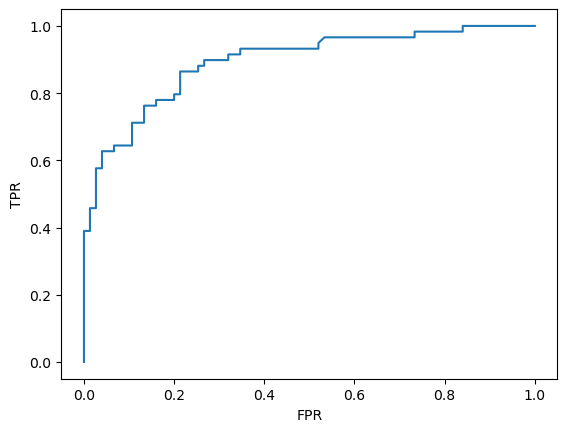

In [96]:
yp=l.predict_proba(xtest)[:,1]
frp,tpr,threshold=roc_curve(ytest,yp)
plt.plot(frp,tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [97]:
threshold

array([       inf, 0.94596238, 0.74924128, 0.74432665, 0.71746857,
       0.71674095, 0.64095059, 0.62670349, 0.62240467, 0.59876686,
       0.59678713, 0.58128793, 0.57226926, 0.55871064, 0.51532906,
       0.50684251, 0.47985041, 0.45647679, 0.45164713, 0.44900504,
       0.44865519, 0.44841383, 0.42990336, 0.37451378, 0.366965  ,
       0.34215602, 0.34208043, 0.24473921, 0.23342103, 0.22887753,
       0.22034254, 0.17140431, 0.16327046, 0.1536322 , 0.13623842,
       0.12995552, 0.10276717, 0.10260071, 0.10259908, 0.09628375,
       0.09496993, 0.04390831])

In [98]:
from sklearn.metrics import f1_score
f1=[f1_score(ytest,(yp>=t).astype(int)) for t in threshold]
best_t=threshold[np.argmax(f1)]
print(f"Best Threshold: {round(best_t,2)}")

Best Threshold: 0.43


In [99]:
# so we will use a threshold of 0.43 insted of 0.5 for better recall score

In [100]:
threshold[22]

0.42990335811935954

In [101]:
from sklearn.preprocessing import binarize
ypr_pr=l.predict_proba(xtest)[:,1]
ypr=binarize([ypr_pr],threshold=0.43)[0]

In [102]:
ypr=ypr.astype(int)

In [103]:
roc_auc_score(ytest,ypr)

0.8170621468926553

In [104]:
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
c=pd.DataFrame(confusion_matrix(ytest,ypr),
              index=["Not Survived","Survived"],
              columns=["Not Survived","Survived"])
print(c)
print("---------------------------------------------------------")
print(classification_report(ytest,ypr))
print("---------------------------------------------------------")
print(accuracy_score(ytest,ypr))

              Not Survived  Survived
Not Survived            59        16
Survived                 9        50
---------------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.79      0.83        75
           1       0.76      0.85      0.80        59

    accuracy                           0.81       134
   macro avg       0.81      0.82      0.81       134
weighted avg       0.82      0.81      0.81       134

---------------------------------------------------------
0.8134328358208955


**parmaetric model** assumes a specific functional form and are discribed by the fix number of parameters regardless of dataset size. it assumes that data follows a known distribusion or equation, fix number of parameters and it is faster to train for example linear regrassion logistic regrassion but the problem with them is they have strong assumptios and give pure performance if assumptions are violated.

**Non parametric model** do not assume a predefined functional form that is there is no strect assumptions about data distribusions . the number of parameters grows with the data it is more flexible but can overfit for example disition trees , random forest, knn etc. 

**dicision tree** is a non parametric supervised learning algorithm used for classification and regrassion it is splits data into branches based on feature values to reach a final dicision. it is start with root node choose the best feature to split the data into child nodes repeate this until a stopping conditions is mate. the final nodes are the  predictions also called as leaf nodes.

Root nodes are the first split representing the entire dataset that is to be analysed or classified. it has no incomming branches but the branches iut into internal nodes that is decision nodes or leaf node that is terminal node which gives the final output.

spliting criteria for classification models are :
1) **gini impurity** :- it measures the probanility of missclassifing a randomly choosen element from a node. the algorithm selects the split that results in the lowest gini impurity that is closes to zero.
gini impurity - 1 - p(sqr) - q(sqr)
2) **entropy and information gain** :- entropy measures the randomness this order or uncertainity of the class distribustion within a node information gain measures reduction in entropy achived by a perticular split the algorithm chooses the split the highest information gain or gratest reduction in entropy.

for regrassion task the goal is to minimise the variance or the spread of data points within each resulting node since MSC(mean squared error) is the most common criteria for regrassion the algorithm seeks to minimize total msc across the child nodes.

**feature selection** choose the most imporatant features from the existing ones they reduce overfitting impoves model speed increase interpretability and remove noise some common methonds of doing feature selection are LASSO regulization feature imporatance by tree chi-square test.                       
**feature extraction** : here the new features are created by transforming existing once for example PCA that is principle component analysis. the feature extraction helps in capturing hidden patterns, reduce dimentionality and improve model power.

**chi-sqauare test** is a statistical test used to check whether to cateegoriacl varibales are related or not in other words it hepls in deciding wheather a perticuler feature is related to a target variable by doing feature selection in classification problems. it comapres the observed values that is the values that we see and expected values that is the values we will se if the varvibles ver independent. if observed is not equale to expected by a large amount then variables are related in ML feature selection features with high chi-square score are importatnt and features with low chi-square are irrelavent.

In [105]:
from sklearn.feature_selection import SelectKBest,chi2

In [106]:
len(df.columns)

7

In [114]:
chi=SelectKBest(chi2,k=4)
xtrain_chi = chi.fit_transform(xtrain,ytrain)
xtest_chi = chi.transform(xtest)


In [115]:
d={
    "Feature":features.columns,
    "Selected":chi.get_support()
}
d1=pd.DataFrame(d)
d1

,Feature,Selected
0,Pclass,True
1,Sex,True
2,Age,False
3,Fare,True
4,Embarked,True
5,FamilySize,False


In [116]:
l=LogisticRegression()
l.fit(xtrain_chi,ytrain)
ypred=l.predict(xtest_chi)

In [118]:
c=pd.DataFrame(confusion_matrix(ytest,ypr),
              index=["Not Survived","Survived"],
              columns=["Not Survived","Survived"])
print(c)
print("---------------------------------------------------------")
print(classification_report(ytest,ypr))
print("---------------------------------------------------------")
print(accuracy_score(ytest,ypr))

              Not Survived  Survived
Not Survived            59        16
Survived                 9        50
---------------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.79      0.83        75
           1       0.76      0.85      0.80        59

    accuracy                           0.81       134
   macro avg       0.81      0.82      0.81       134
weighted avg       0.82      0.81      0.81       134

---------------------------------------------------------
0.8134328358208955


**KNN** : K Neafrest neghbours is highly interpritable non paramteric model lassy learner that makes no assumption about the underline data distribusion. it conciders k closest data points or neighbours based on distance metrix for classification it does majority voting and predict the most freqant class for regrassion it calculates average k neghbours to predict as target value it is cretical highper parameter is n_neighbars denoted by k. small k value results in low bies high varince. and can leas to overfitting large k value can result in high bies low varince which may result tinunderfitting so k is generally taken balnce bies varince trade of and it is generally odd to avoid ties. in binary classification. beacuse KKn is based on distance it is extremally sensitive to feature scale so feature scalling like standard scaller is appied to ensure features with larger numerical ranges do not dominate the distance calculation.

In [119]:
from sklearn.neighbors import KNeighborsClassifier

In [121]:
knn = KNeighborsClassifier()
knn.fit(xtrain,ytrain)
ypred=knn.predict(xtest)

print(f"traning score: {knn.score(xtrain,ytrain)}")
print(f"testing score: {knn.score(xtest,ytest)}")
c=pd.DataFrame(confusion_matrix(ytest,ypr),
              index=["Not Survived","Survived"],
              columns=["Not Survived","Survived"])
print(c)
print("---------------------------------------------------------")
print(classification_report(ytest,ypr))
print("---------------------------------------------------------")
print(accuracy_score(ytest,ypr))

traning score: 0.8582781456953642
testing score: 0.746268656716418
              Not Survived  Survived
Not Survived            59        16
Survived                 9        50
---------------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.79      0.83        75
           1       0.76      0.85      0.80        59

    accuracy                           0.81       134
   macro avg       0.81      0.82      0.81       134
weighted avg       0.82      0.81      0.81       134

---------------------------------------------------------
0.8134328358208955


In [122]:
# hyper parameter tuning
trainac=[]
testac=[]

for i in range(3,51,2):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(xtrain,ytrain)
    trainac.append(knn.score(xtrain,ytrain))
    testac.append(knn.score(xtest,ytest))

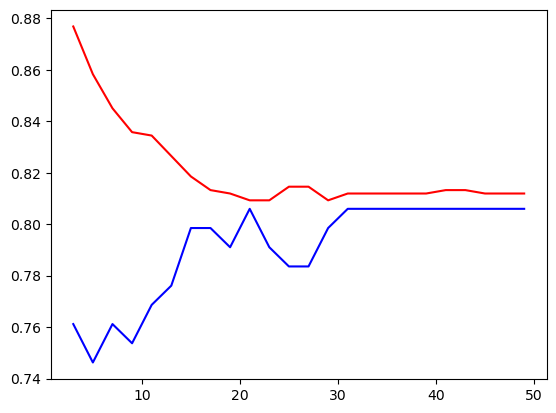

In [123]:
plt.plot(range(3,51,2),trainac,color="red")
plt.plot(range(3,51,2),testac,color="blue")
plt.show()

In [124]:
knn = KNeighborsClassifier(n_neighbors=21)
knn.fit(xtrain,ytrain)
ypred=knn.predict(xtest)

print(f"traning score: {knn.score(xtrain,ytrain)}")
print(f"testing score: {knn.score(xtest,ytest)}")
c=pd.DataFrame(confusion_matrix(ytest,ypr),
              index=["Not Survived","Survived"],
              columns=["Not Survived","Survived"])
print(c)
print("---------------------------------------------------------")
print(classification_report(ytest,ypr))
print("---------------------------------------------------------")
print(accuracy_score(ytest,ypr))

traning score: 0.8092715231788079
testing score: 0.8059701492537313
              Not Survived  Survived
Not Survived            59        16
Survived                 9        50
---------------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.79      0.83        75
           1       0.76      0.85      0.80        59

    accuracy                           0.81       134
   macro avg       0.81      0.82      0.81       134
weighted avg       0.82      0.81      0.81       134

---------------------------------------------------------
0.8134328358208955
